In [1]:
import os
import json

import yaml
import rasterio

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

from rasterio.enums import Resampling
from rasterio.io import MemoryFile
from rasterio.mask import mask
from rasterio.warp import reproject
from pathlib import Path

In [2]:
os.chdir("..")

In [3]:
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

In [4]:
# project paths
data_dir = Path(config["data_dir"])
data_dir_raw = data_dir / "raw"
data_dir_processed = data_dir / "processed"

aoi_path = data_dir / "aoi.geojson"

band_paths = [path for path in data_dir_raw.rglob("*.jp2")]
bands_dir = list(set([band.parent for band in band_paths]))[0]

In [5]:
scale_factor = 10000

### Helper functions

In [6]:
# scale digital numbers to surface reflectance
def scale_reflectance(band, scale_factor):
    return band / scale_factor

In [7]:
# cloud masking
def create_cloud_mask(scl, cloud_classes):
    return ~np.isin(scl, cloud_classes)

### Data preparation

In [8]:
# open a reference dataset
with rasterio.open(band_paths[1]) as ref:
    ref_band = ref.read(1).astype("float32")
    ref_profile = ref.profile.copy()
    ref_profile.update(
        dtype="float32"
    )

In [9]:
# 0	No data
# 1	Saturated/defective
# 2	Topographic casted shadows
# 3	Cloud shadows
# 4	Vegetation
# 5	Bare soils
# 6	Water
# 7	Unclassified
# 8	Cloud, medium probability
# 9	Cloud, high probability
# 10 Thin cirrus
# 11 Snow/ice

In [10]:
# create a cloud mask
scl_band_path = band_paths[-1]

with rasterio.open(scl_band_path) as scl:
    scl_data = scl.read(1)
    scl_profile = scl.profile.copy()

    scl_10m = np.empty(ref_band.shape, dtype=np.uint8)
    
    reproject(
        source=scl_data.astype(np.uint8),
        destination=scl_10m,
        src_transform=scl.transform,
        src_crs=scl.crs,
        dst_transform=ref_profile["transform"],
        dst_crs=ref_profile["crs"],
        reesampling=Resampling.nearest
    )

cloud_classes = [0, 1, 3, 7, 8, 9, 10, 11]
cloud_mask = create_cloud_mask(scl_10m, cloud_classes)

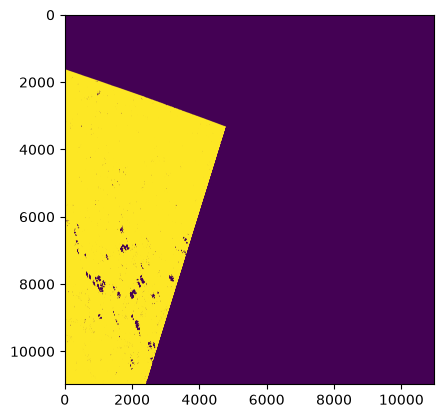

In [11]:
plt.imshow(cloud_mask)

In [12]:
aoi = gpd.read_file(aoi_path)

In [13]:
# prepare bands for analysis
for band in band_paths:
    b = band.name[-11:-8]
    if b in ["SCL"]:
        continue
    with rasterio.open(band) as src:
        data = src.read(1)
        profile = src.profile.copy()
        
        # scale digital numbers to surface reflectance
        data = scale_reflectance(data, scale_factor)
        
        print("\n===========================================\n")
        print(f"Scale reflectance:\nband: {b}\nmin: {data.min()}\nmax: {data.max()}")
        
        data = data.astype("float32")
        print(f"data dtype: {data.dtype}")
        
        # reshape to 10 m resolution
        if band.name[-8:-4] in ["_20m", "_60m"]:
            dest_10m = np.empty(ref_band.shape, dtype=ref_band.dtype)
            reproject(
                source=data,
                destination=dest_10m,
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=ref_profile["transform"],
                dst_crs=ref_profile["crs"],
                resampling=Resampling.bilinear
            )

            data = dest_10m
            assert ref_band.shape == dest_10m.shape, "WARNING: Wrong shape!"
        
        # apply cloud mask
        data[cloud_mask == 0] = np.nan

        # update profile
        profile.update(
            height=ref_profile["height"],
            width=ref_profile["width"],
            transform=ref_profile["transform"],
            crs=ref_profile["crs"],
            driver="GTiff",
            dtype="float32",
            nodata=np.nan
        )
        
        # clip to the AOI
        with MemoryFile() as memfile:
            with memfile.open(**profile) as dataset:
                dataset.write(data, 1)

                clipped, transform = mask(
                    dataset,
                    aoi.geometry,
                    nodata=np.nan,
                    crop=True,
                    filled=False,
                	all_touched=True
                )
                clipped_profile = profile.copy()
                clipped_profile.update(
                    height=clipped.shape[1],
                    width=clipped.shape[2],
                    transform=transform
                )        
        print(f"\nAfter clipping:\nmin: {clipped.min()}\nmax: {clipped.max()}")
        
        processed_filename = band.name.replace(band.name[-8:], "_10m.tif")
        processed_path = data_dir_processed / processed_filename
        
        with rasterio.open(processed_path, "w", **clipped_profile) as dst:
            dst.write(clipped)



Scale reflectance:
band: B01
min: 0.0
max: 0.8244
data dtype: float32

After clipping:
min: 0.02696250006556511
max: 0.42222779989242554


Scale reflectance:
band: B02
min: 0.0
max: 1.3832
data dtype: float32

After clipping:
min: 0.09989999979734421
max: 0.8158000111579895


Scale reflectance:
band: B03
min: 0.0
max: 1.7699
data dtype: float32

After clipping:
min: 0.042100001126527786
max: 0.8841999769210815


Scale reflectance:
band: B04
min: 0.0
max: 1.7045
data dtype: float32

After clipping:
min: 0.07119999825954437
max: 0.8680999875068665


Scale reflectance:
band: B05
min: 0.0
max: 1.6839
data dtype: float32

After clipping:
min: 0.06766875088214874
max: 0.6664937734603882


Scale reflectance:
band: B06
min: 0.0
max: 1.2862
data dtype: float32

After clipping:
min: 0.06480000168085098
max: 0.6577812433242798


Scale reflectance:
band: B07
min: 0.0
max: 0.9794
data dtype: float32

After clipping:
min: 0.065700002014637
max: 0.6939937472343445


Scale reflectance:
band: B08
min